<h1 style="color:orange; font-weight:bold">🔄 Data Transformation</h1>

<div align="center">

<img src="06_scaling.png" alt="Missing Values Handling — From Basic to Advanced" width="100%">

</div>

**Data Transformation = Converting raw data into a more suitable form for analysis and Machine Learning.**

### ✅ Benefits

* 📏 Makes feature scales more comparable
* 📊 Improves data distribution
* 🤖 Can improve model performance
* ⚡ Can make model training more efficient

### ⚠️ If Not Performed When Needed

* 📏 Different scales may cause some features to **dominate**
* 🤖 Some ML models may perform **poorly**
* 📊 Skewed data can affect **analysis and modeling**
* 🐌 Training may become **less efficient**

> 💡 **Rule:** Transform data when its **scale or distribution can negatively affect your analysis or model.**
---
---

<h3 style="color:orange; font-weight:bold">📏 StandardScaler</h3>


- **Standard Scaling = Converts data so that its Mean becomes `0` and Standard Deviation becomes `1`.**
- It brings different features to a **comparable scale**.
- Formula:

  **`z = (x − Mean) / Standard Deviation`**

### Example

Suppose:

`Age = 20, 30, 40`

After Standard Scaling:

`≈ -1.22, 0, +1.22`

👉 **Mean → 0**  
👉 **Standard Deviation → 1**

> 💡 **Rule:** StandardScaler → **Mean = 0, Standard Deviation = 1.**
---

In [1]:
# Import Libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

In [2]:
# Create Dataset
df = {
    'age': [25,30,35,40,45],
    'height': [165,170,175,180,185],
    'weight': [55,60,65,70,75]
}

# Convert into Pandas DataFram
df = pd.DataFrame(df)
df.head()

,age,height,weight
0,25,165,55
1,30,170,60
2,35,175,65
3,40,180,70
4,45,185,75


In [3]:
# Import Scalar
scalar = StandardScaler()

In [4]:
# fit the scalar on data
scaled_df = scalar.fit_transform(df)
scaled_df

array([[-1.41421356, -1.41421356, -1.41421356],
       [-0.70710678, -0.70710678, -0.70710678],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.70710678,  0.70710678,  0.70710678],
       [ 1.41421356,  1.41421356,  1.41421356]])

In [5]:
# convert this data into a pandas dataframe
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,-1.414214,-1.414214,-1.414214
1,-0.707107,-0.707107,-0.707107
2,0.000000,0.000000,0.000000
3,0.707107,0.707107,0.707107
4,1.414214,1.414214,1.414214


---
<h3 style="color:orange; font-weight:bold">📏 MinMaxScaler</h3>

- **MinMaxScaler = Rescales data into a fixed range**, usually **`0 to 1`**.
- The **minimum value becomes `0`**.
- The **maximum value becomes `1`**.
- All other values are placed **between 0 and 1**.

### Example

Original:

`10, 20, 30, 40, 50`

After MinMax Scaling:

`0, 0.25, 0.5, 0.75, 1`

👉 **Min = 0**  
👉 **Max = 1**

> 💡 **Rule:** MinMaxScaler → **Fixed range (usually 0 to 1).**
---

In [6]:
# Import the Scalar
scalar = MinMaxScaler()

# Fit the Scalar on Data
scaled_df = scalar.fit_transform(df)

# Convert into Pandas Dataframe
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,0.00,0.00,0.00
1,0.25,0.25,0.25
2,0.50,0.50,0.50
3,0.75,0.75,0.75
4,1.00,1.00,1.00


---
<h3 style="color:orange; font-weight:bold">➕➖ MaxAbsScaler</h3>

- **MaxAbsScaler = Scales data by dividing each value by the maximum absolute value.**
- It scales values into the range **`-1 to +1`**.
- ✅ It **preserves the sign** of the values.
- `Negative → Negative` and `Positive → Positive`

### Example

Original:

`-100, -50, 0, 50, 100`

After MaxAbs Scaling:

`-1, -0.5, 0, 0.5, 1`

👉 **Maximum Absolute Value = 100**

> 💡 **Rule:** MaxAbsScaler → **Range -1 to +1 while preserving positive and negative signs.**
---

In [7]:
# Import the Scalar
scalar = MaxAbsScaler()

# Fit the Scalar on Data
scaled_df = scalar.fit_transform(df)
scaled_df

# Convert this Data into a Pandas Dataframe
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,0.555556,0.891892,0.733333
1,0.666667,0.918919,0.800000
2,0.777778,0.945946,0.866667
3,0.888889,0.972973,0.933333
4,1.000000,1.000000,1.000000


---
<h3 style="color:orange; font-weight:bold">🛡️ RobustScaler</h3>

- **RobustScaler = Scaling method that is less affected by outliers.**
- It uses **Median** and **IQR (Interquartile Range)** instead of Mean and Standard Deviation.
- ✅ Useful when the dataset contains **outliers**.
- ⚠️ It does **not** have a fixed range like MinMaxScaler.

### Example

Original:

`10, 12, 13, 15, 100`

👉 `100` = **Outlier**

**RobustScaler → Median + IQR**

So, the effect of `100` is **reduced** during scaling.

> 💡 **Rule:** Outliers present → **Consider RobustScaler.**
---

In [8]:
from sklearn.preprocessing import RobustScaler

# Import the Scalar
scalar = RobustScaler()

# Fit the Scalar on Data
scaled_df = scalar.fit_transform(df)
scaled_df

# Convert this Data into a Pandas Dataframe
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,-1.0,-1.0,-1.0
1,-0.5,-0.5,-0.5
2,0.0,0.0,0.0
3,0.5,0.5,0.5
4,1.0,1.0,1.0


In [9]:
df.head()

,age,height,weight
0,25,165,55
1,30,170,60
2,35,175,65
3,40,180,70
4,45,185,75


---
<h1 style="color:orange; font-weight:bold">📐 Normalization</h1>

- **Normalization = Rescaling each data point based on its overall magnitude (norm).**
- It is usually applied **row-wise (sample-wise)**, not column-wise.
- Common types: **L1 Normalization** and **L2 Normalization**.
- ✅ Useful when the **relative proportion/direction** of features matters.

### Example

Original row:

`[3, 4]`

After normalization:

`[0.6, 0.8]`

👉 The data is transformed so its **overall magnitude is controlled**.

> 💡 **Rule:** Normalization → **Control the magnitude of each sample.**

---
<h3 style="color:orange; font-weight:bold">➗ L1 Normalization</h3>

- **L1 Normalization = Divides each value by the sum of absolute values in that row.**
- After L1 normalization, the **sum of absolute values = 1**.
- ✅ Useful when the **proportion of features** is important.

### Example

Original:

`[3, 4]`

L1 Norm:

`|3| + |4| = 7`

After L1 Normalization:

`[3/7, 4/7]`

👉 `[0.43, 0.57]`

> 💡 **Rule:** L1 Normalization → **Sum of absolute values = 1.**

In [10]:
# Import Liberary
from sklearn.preprocessing import Normalizer

In [11]:
# Create Dataset
data = [[1, 1, 1], [1, 1, 0], [1, 0, 0]]

In [12]:
# Import Normilizer
normalizer = Normalizer(norm='l1')

In [13]:
print(normalizer.fit_transform(data))

[[0.33333333 0.33333333 0.33333333]
 [0.5        0.5        0.        ]
 [1.         0.         0.        ]]


---
<h3 style="color:orange; font-weight:bold">📐 L2 Normalization</h3>

- **L2 Normalization = Divides each value by the L2 norm of that row.**
- After L2 normalization, the **sum of squared values = 1**.
- The **L2 norm (magnitude) = 1**.

### Example

Original:

`[3, 4]`

L2 Norm:

`√(3² + 4²) = 5`

After L2 Normalization:

`[3/5, 4/5]`

👉 `[0.6, 0.8]`

> 💡 **Rule:** L2 Normalization → **L2 norm = 1.**
---

In [14]:
# Import Liberary
from sklearn.preprocessing import Normalizer

In [15]:
# Create Dataset
data = [[1, 1, 1], [1, 1, 0], [1, 0, 0]]

In [16]:
# Import Normilizer
normalizer = Normalizer(norm='l2')

In [17]:
print(normalizer.fit_transform(data))

[[0.57735027 0.57735027 0.57735027]
 [0.70710678 0.70710678 0.        ]
 [1.         0.         0.        ]]


---
<h1 style="color:orange; font-weight:bold">📊 Distribution Transformation</h1>

- **Distribution Transformation = Changes the shape/distribution of data.**
- It can help reduce **skewness** and make data more suitable for analysis or Machine Learning.
- It **changes the actual values** of the data.
- Common methods:
  - 🔢 **Log Transformation**
  - 📈 **Box-Cox**
  - 📊 **Yeo-Johnson**
  - 📐 **Quantile Transformation**

### Example

Right-skewed data:

`10, 20, 30, 100, 1000`

👉 After a suitable transformation, the values and their **distribution shape** can become less skewed.

> 💡 **Rule:** Distribution Transformation → **Change the data's distribution, not just its scale.**
---

---
<h3 style="color:orange; font-weight:bold">🔢 Log Transformation</h3>

- **Log Transformation = Applies a logarithmic function to numerical values.**
- It **compresses large values** and can reduce **right-skewness**.
- It is useful when a few very large values dominate the data.
- ⚠️ Standard log requires **positive values**.

### Example

Original:

`10, 100, 1000`

After `log10`:

`1, 2, 3`

👉 Large values become **closer together**.

> 💡 **Rule:** Log Transformation → **Compress large values and reduce skewness.**
---

In [18]:
# Import Liberary
import pandas as pd
import numpy as np
import seaborn as sns

In [29]:
# Create Dataset with Skewed Values
df = { "Values": [1,5,10,20,50,100,200,500,1000,2000,5000,10000,20000,50000,100000]}

In [30]:
# Convert into Pandas DataFrame
df = pd.DataFrame(df)
df.head()

,Values
0,1
1,5
2,10
3,20
4,50


In [31]:
# Convert into Log Transformation
df['log'] = np.log(df['Values'])
df['log2'] = np.log2(df['Values'])
df['log10'] = np.log10(df['Values'])
df.head()

,Values,log,log2,log10
0,1,0.000000,0.000000,0.00000
1,5,1.609438,2.321928,0.69897
2,10,2.302585,3.321928,1.00000
3,20,2.995732,4.321928,1.30103
4,50,3.912023,5.643856,1.69897


In [32]:
# Log Transform

df.head()

,Values,log,log2,log10
0,1,0.000000,0.000000,0.00000
1,5,1.609438,2.321928,0.69897
2,10,2.302585,3.321928,1.00000
3,20,2.995732,4.321928,1.30103
4,50,3.912023,5.643856,1.69897


### 1️⃣ Box-Cox Transformation

**Positive values ko transform karke skewness kam karta hai.**

Example:

`[10, 100, 1000]`

Log-like transformation se:

`[1, 2, 3]`

👉 **Positive values only.**

---

### 2️⃣ Yeo-Johnson Transformation

**Positive, zero aur negative values ko transform karke skewness kam karta hai.**

Example:

`[-100, -10, 0, 10, 100]`

👉 Transformation ke baad values ka distribution **more balanced** ho sakta hai.

👉 **Negative + Zero + Positive values allowed.**

---

### 3️⃣ Quantile Transformation

**Values ki rank/position ke according data ko transform karta hai.**

Example:

`[10, 20, 30, 40, 50]`

Ranks:

`1 → 2 → 3 → 4 → 5`

👉 In ranks ko **Uniform** ya **Normal distribution** mein map kiya ja sakta hai.

> 💡 **Rule:**  
> **Box-Cox → Positive only**  
> **Yeo-Johnson → Positive + Zero + Negative**  
> **Quantile → Rank/Quantile based transformation**
---

In [22]:
# Import Liberary
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import QuantileTransformer

In [23]:
# Generate Non-Normal Data
np.random.seed(0)
df = np.random.exponential(size=1000, scale=2)
df = pd.DataFrame(df, columns=['values'])
df.head()

,values
0,1.591749
1,2.511862
2,1.846446
3,1.574402
4,1.102097


In [24]:
## Load All Transformer
pt_boxcox = PowerTransformer(method='box-cox', standardize=False)
pt_yeo_johnson = PowerTransformer(method='yeo-johnson', standardize=False)
qt_normal = QuantileTransformer(output_distribution='normal')

In [25]:
# BoxCox Values Must Be Positive
df['Box_Cox'] = pt_boxcox.fit_transform(df[['values']] + 1)
df['Yeo_Johnson'] = pt_yeo_johnson.fit_transform(df[['values']])
df['Quantile'] = qt_normal.fit_transform(df[['values']])

In [26]:
df.head()

,values,Box_Cox,Yeo_Johnson,Quantile
0,1.591749,0.787485,0.787485,0.162552
1,2.511862,0.980233,0.980233,0.587964
2,1.846446,0.849553,0.849553,0.286135
3,1.574402,0.782945,0.782945,0.157469
4,1.102097,0.639848,0.639848,-0.154930


NameError: name 'plt' is not defined

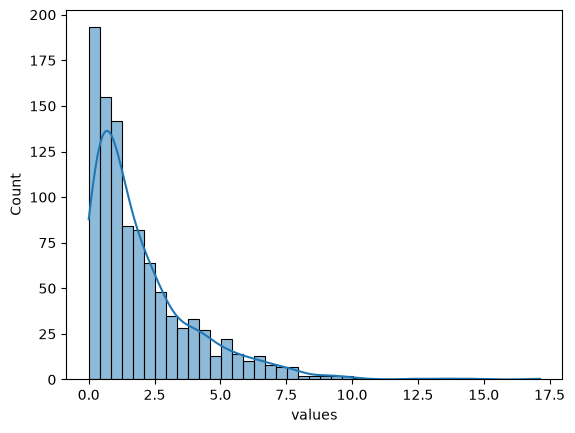

In [27]:
for col in df.columns:
    sns.histplot(df[col], kde=True)
    plt.show()